<img src="https://raw.githubusercontent.com/ChristophWuersch/FeatureEngineering_HS2026/main/mse_logo.png" width="400" align="right"/>
<div style="text-align: left"> <b> Machine Learning FTP_MachLe </b> <br> HS 2026 <br> <a href="mailto:christoph.wuersch@ost.ch"> Christoph Würsch </a> </div>

In [3]:
# imports
from IPython.display import Image, display
from IPython.display import HTML
import os
import requests
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# allow plots to appear directly in the notebook
%matplotlib inline

# raw URL of this repository on GitHub (images, data)
filepath = "https://raw.githubusercontent.com/ChristophWuersch/FeatureEngineering_HS2026/main"

# **Feature Engineering – Group 2: Feature Transformation**

**Authors:** *Nora Beringer, Malte Gerboth, Haben Ghebremeskel Tekle, Janic Rüegg, Daniel Chung, Raphael Lüthy*

<img src="https://raw.githubusercontent.com/ChristophWuersch/FeatureEngineering_HS2026/main/images/02_Feature_Transformation.png" width="1200"/>

## Introduction

**What is it about?**
*Feature transformation* changes the representation of a feature so that a model can use it more easily. Monotonic transforms such as the logarithm or the square root compress long-tailed distributions and turn multiplicative effects into additive ones. Categorical variables must be turned into numbers, via one-hot encoding for nominal and label (ordinal) encoding for ordered categories. Polynomial features let linear models capture non-linear relationships, and periodic features such as time of day, weekday or angle are best encoded with sine/cosine pairs or radial basis functions so that "23:59" and "00:01" end up close together.

**Where is it used?**
Everywhere tabular data is modelled: prices and incomes (log transform), customer or product categories (one-hot encoding), physical models with interactions (polynomial features), and time series with daily, weekly or seasonal cycles such as energy demand, traffic or sales forecasting (cyclic encoding).

**Why is it important for Machine Learning?**
Most learners make implicit assumptions about their inputs: linear models assume linear effects, distance-based models assume meaningful distances, and no model can directly digest strings. A well-chosen transformation can turn a hard problem into an easy one, often with a simpler model. A poorly chosen one (e.g. label-encoding nominal categories or blindly one-hot encoding high-cardinality features) introduces false orderings, sparsity and the curse of dimensionality.

## (i) Why and when feature transformations make sense



**Why?**  
Feature transformations make sense when the original features do not fit the assumptions or requirements of the machine learning model.

**What do they do?**  
They reshape features to make their **distribution, scale, or relationships** more suitable for modeling.

**When?**
- **Different scales** → standardization / normalization
- **Skewed data** → log or other mathematical transformations
- **Outliers** → transformations can reduce their influence
- **Categorical data** → encode categories numerically
- **Nonlinear relationships** → transform features to make patterns easier to model

**Key idea:**  
> **Transform the features when their current representation makes it harder for the model to learn effectively.**


## (ii) Log, square root, and monotonic transforms

**Summary:** Use the log for strongly right skewed, positive data such as income or prices, and the square root for moderately skewed data such as counts, where the log would go too far. Both are monotonic transforms, so they help linear and distance based models, but make no difference for tree based models.

### 1. Log transform

**Reason:** In long tailed features a few extreme values dominate the model. The log compresses them and turns multiplicative effects into additive ones.

**Usage:** Strictly positive, strongly right skewed data such as income, prices or web traffic. With zeros use log(1 + x) (`np.log1p`).

**In a nutshell:** x' = log(x). Equal ratios become equal distances, so the step from 10 to 100 is as large as from 100 to 1000.

**Python:** `np.log(x)`, or `np.log1p(x)` if the data contains zeros.

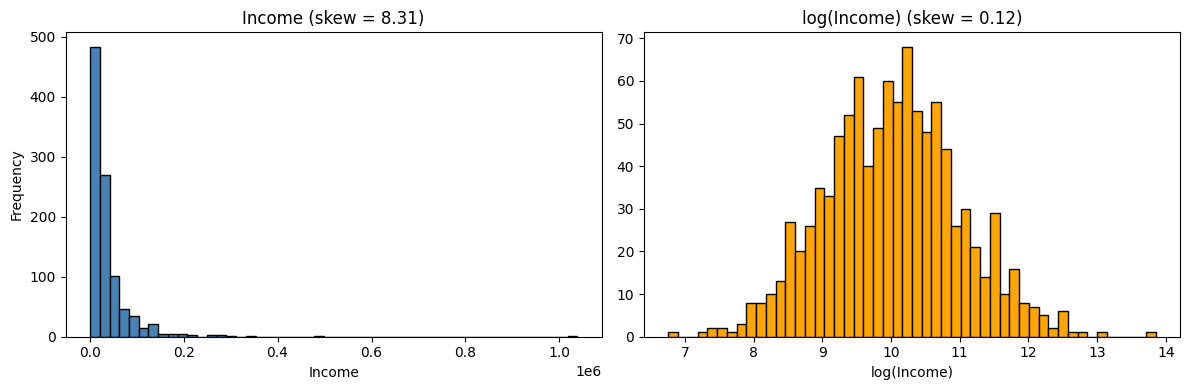

In [4]:
# Simulate right skewed income: few very high values, many low ones
np.random.seed(42)
income = np.random.lognormal(mean=10, sigma=1, size=1000)

# Log transform compresses the long tail
log_income = np.log(income)

# Histograms before and after, skewness in the title (0 = symmetric)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(income, bins=50, edgecolor='black', color='steelblue')
axes[0].set_title(f'Income (skew = {pd.Series(income).skew():.2f})')
axes[0].set_xlabel('Income')
axes[0].set_ylabel('Frequency')
axes[1].hist(log_income, bins=50, edgecolor='black', color='orange')
axes[1].set_title(f'log(Income) (skew = {pd.Series(log_income).skew():.2f})')
axes[1].set_xlabel('log(Income)')
plt.tight_layout()
plt.show()

**Source:** Wikipedia, «Data transformation (statistics)»: https://en.wikipedia.org/wiki/Data_transformation_(statistics)

### 2. Square root transform

**Reason:** Milder than the log. Fits moderately skewed data where the log would overcorrect.

**Usage:** Non negative, moderately right skewed data such as counts or waiting times. Zeros are allowed.

**In a nutshell:** x' = √x. Pulls in large values, but less strongly than the log.

**Python:** `np.sqrt(x)`.

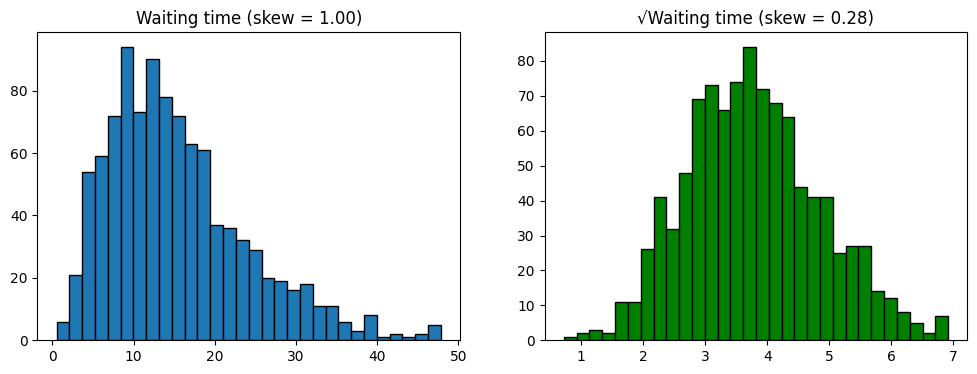

In [9]:
# Moderately right skewed data, e.g. waiting time in minutes
np.random.seed(42)
wait = np.random.gamma(shape=3, scale=5, size=1000)

# Square root transform pulls in the long right tail
sqrt_wait = np.sqrt(wait)

# Before and after, skewness in the title (0 = symmetric)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(wait, bins=30, edgecolor='black')
axes[0].set_title(f'Waiting time (skew = {pd.Series(wait).skew():.2f})')
axes[1].hist(sqrt_wait, bins=30, edgecolor='black', color='green')
axes[1].set_title(f'√Waiting time (skew = {pd.Series(sqrt_wait).skew():.2f})')
plt.show()

**Source:** GeeksforGeeks, «Square Root Transformation»: https://www.geeksforgeeks.org/data-analysis/square-root-transformation/

### 3. Other monotonic transforms

**Reason:** Log and square root only work for values ≥ 0 and you have to pick them by hand. Other monotonic transforms also handle negative values or choose the best transform automatically.

**Usage:**
1. `np.cbrt(x)` (cube root): skewed data with negative values.
2. `np.arcsinh(x)`: behaves like log, but works with 0 and negative values.
3. `PowerTransformer()`: finds the best power automatically (Yeo Johnson or Box Cox).
4. `QuantileTransformer()`: replaces each value by its rank and maps it to a normal or uniform distribution. Robust to outliers.

They help linear models and kNN. Trees don't need them, because the order of the values stays the same.

**In a nutshell:** A monotonic function never decreases (or never increases). The order of the values is kept, only the distances between them change.

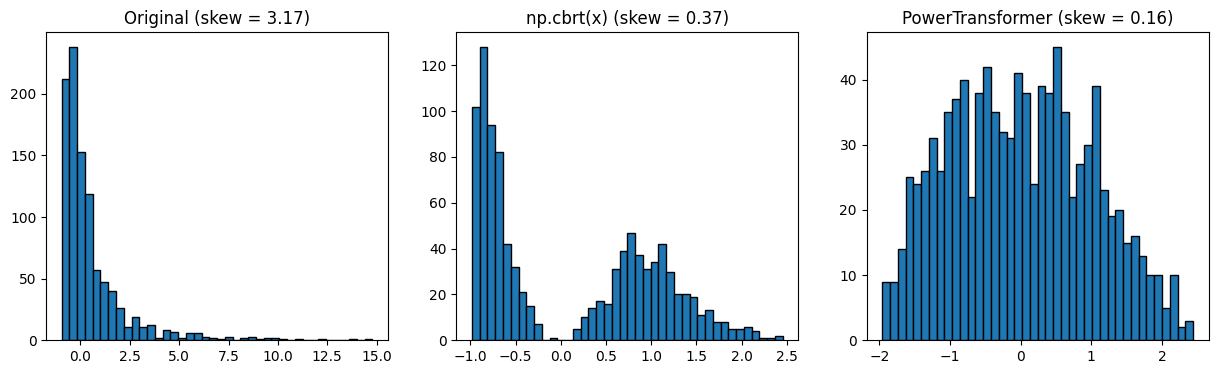

In [6]:
from sklearn.preprocessing import PowerTransformer

# Right skewed data with negative values (log would fail here)
np.random.seed(0)
x = np.random.lognormal(size=1000) - 1

# Cube root by hand vs PowerTransformer, which picks the best power itself (needs a 2D column)
data = {'Original': x,
        'np.cbrt(x)': np.cbrt(x),
        'PowerTransformer': PowerTransformer().fit_transform(x.reshape(-1, 1)).ravel()}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, values) in zip(axes, data.items()):
    ax.hist(values, bins=40, edgecolor='black')
    ax.set_title(f'{name} (skew = {pd.Series(values).skew():.2f})')
plt.show()

## (iii) Categorical features: nominal → one-hot encoding, ordinal → label encoding



## (iv) Problems with one-hot encoding (sparsity, curse of dimensionality)



## (v) Polynomial features



## (vi) Periodic features: sine/cosine encoding and radial basis functions



## Takeaways

- **What should every ML practitioner remember?**
  - ...
- **What are common pitfalls?**
  - ...
- **When does this technique really matter?**
  - ...

## References

*Cite the sources of all figures, diagrams and code snippets (URLs are sufficient).*

1. https://www.geeksforgeeks.org/machine-learning/feature-transformation-techniques-in-machine-learning/
2. Finney DJ. Was This in Your Statistics Textbook? V. Transformation of Data. Experimental Agriculture. 1989;25(2):165-175. doi:10.1017/S0014479700016665
3. https://www.analyticsvidhya.com/blog/2021/05/feature-transformations-in-data-science-a-detailed-walkthrough/